This notebook is to help students beginning with EDA and ML.
The basic steps are:
1. Import the necessary stuff.
2. Load the data.
3. Examine null percentages in train and test data attributewise
4. Examine class distribution, in this case distribution of Survived
5. From the movie, we can guess that more females should have been survived than males. Examine that.
6. Pclass (proxy for social status) might have played some role in not survival as priority among same gender type may be based on that. So, Examine Pclass among the females who did not survive.
7. Let us try to visualize a few relations using seaborn
8. Create a new feature - Salutation, merge similar Salutations, i.e. replace similar salutations with one and find meadian age Salutationwise. Impute Age Salutationwise (e.g. handle missing value in age Salutationwise).
9. Construct a new attribute, let us name it 'GenderPlus' with possible values female, boy and male. This is because we suspect that boys might had better chance of survival than adult males.
10. Visualize the survuval percentage of boys vs adult males to test the above point.
11. Construct a new feature Family_Size as the sum of SibSp (Sibling and Spouce), Parch (Parents and Children) + 1.
12. Construct FamilySurvivalRate. The hypothesis is that if somebody from a family of a passenger under focus is survived then the chances of that passenger survived is also more.
13. LabelEncode GenderPlus and Sex
14. There is a missing value in Fare, impute it and create Fare_Bins and Fare_Code
15. Do anomaly detection using pycaret.anomaly
16. Use only Gender, GenderPlus, FamilySize, FamilySurvivalRate and Pclass attribute in the final training and testing set (We tried others but this set of attributes worked well).
17. Use XGBClassifier with hyperparameter tuning.

That is it.

The notebook is not original and it is inspired from many excellent notebooks available in the public domain on Kaggle. Some of the excellent notebooks from which this notebook has taken clues include:

https://www.kaggle.com/pliptor/how-am-i-doing-with-my-score

https://www.kaggle.com/mrisdal/exploring-survival-on-the-titanic

https://www.kaggle.com/cdeotte/titantic-mega-model-0-84210

https://www.kaggle.com/konstantinmasich/titanic-0-82-0-83

https://www.kaggle.com/tomigelo/titanic-with-family-survival-tpot-0-81818

https://www.kaggle.com/cdeotte/titanic-wcg-xgboost-0-84688

I hope the notebook will be helpful. Do Upvote if you find it useful.

In [1]:
#Importing
#Importing a few extra classifiers and stats which I may not use. Those can be removed.
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

#setting sns
sns.set(style='white', context='notebook', palette='deep')

from scipy.stats import mode, norm, skew, kurtosis
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier, VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, GridSearchCV

#handle warnings
import warnings
warnings.filterwarnings('ignore')

#ensuring inline display of plots
get_ipython().run_line_magic('matplotlib', 'inline')

In [2]:
#Checking for GPU
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


In [3]:
#read data files
trdf=pd.read_csv("/kaggle/input/content/train.csv", header='infer')
tsdf=pd.read_csv("/kaggle/input/content/test.csv", header='infer')
submission=pd.read_csv('/kaggle/input/content/gender_submission.csv',header='infer')

#Take a glimpse at the data
print(trdf.head())
#tsdf.head()

#trdf.describe()
#tsdf.describe()

#observe data types and missing values
trdf.info()
tsdf.info()

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
<c

In [4]:
#Examine Null Percentages in train attributewise
per_null_series=(trdf.isnull().sum()/len(trdf))*100
print(type(per_null_series))
print(per_null_series)
sorted_per_null_series=per_null_series.sort_values(ascending=False)
print(sorted_per_null_series)
temp=pd.DataFrame({"Missing Ratio in Train":sorted_per_null_series})
print(temp.head())

#Examine null percentages in test attributewise
per_null_series_test=(tsdf.isnull().sum()/len(tsdf))*100
sorted_per_null_series_test=per_null_series_test.sort_values(ascending=False)
temp_ts=pd.DataFrame({"Percentage Missing Value in Test":sorted_per_null_series_test})
print(temp_ts)

#In output, observe that missing percentages are almost same in train and test, so that is good

<class 'pandas.core.series.Series'>
PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64
Cabin          77.104377
Age            19.865320
Embarked        0.224467
PassengerId     0.000000
Name            0.000000
Pclass          0.000000
Survived        0.000000
Sex             0.000000
Parch           0.000000
SibSp           0.000000
Fare            0.000000
Ticket          0.000000
dtype: float64
             Missing Ratio in Train
Cabin                     77.104377
Age                       19.865320
Embarked                   0.224467
PassengerId                0.000000
Name                       0.000000
             Percentage Missing Value in Test
Cabin                               78.229665
Age                       

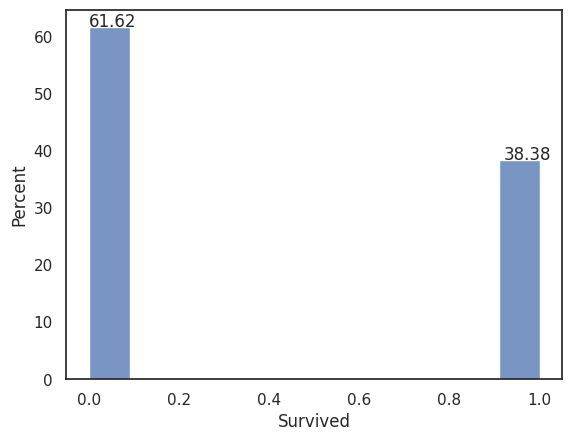

In [5]:
sns.histplot(x="Survived", stat="percent", data=trdf) #This works

per_class0=round(((trdf.loc[:,"Survived"]==0).sum()/len(trdf))*100,2)
per_class1=round(((trdf.loc[:,"Survived"]==1).sum()/len(trdf))*100,2)

for i, fr in [(0,per_class0), (0.92,per_class1)]:
    plt.text(i, fr+0.1, str(fr))

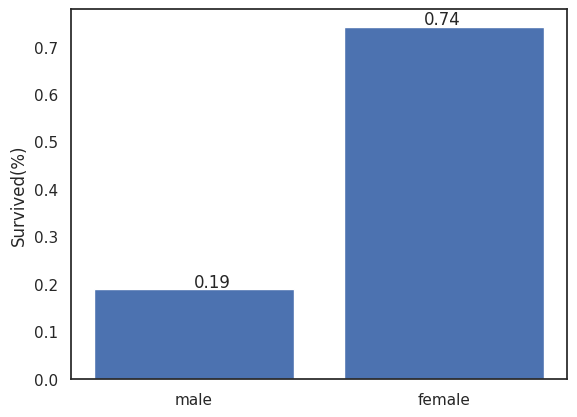

In [6]:
#We have seen the movie, we suspect more females should have been survived.
#Let us examine percentage of male and female survived
per_males= ( (trdf.loc[:,"Sex"]=="male") & (trdf.loc[:,"Survived"]==1) ).sum()/(trdf.loc[:,"Sex"]=="male").sum()
per_females=( (trdf.loc[:,"Sex"]=="female") & (trdf.loc[:,"Survived"]==1) ).sum()/(trdf.loc[:,"Sex"]=="female").sum()

plt.bar(x=["male", "female"], height=[per_males, per_females])
plt.ylabel("Survived(%)")


for x,per in [(0,per_males), (0.92, per_females)]:
    plt.text(x,per+0.005, str(round(per,2)))

#Output shows that only 19% males survived while this is almost 74% in females

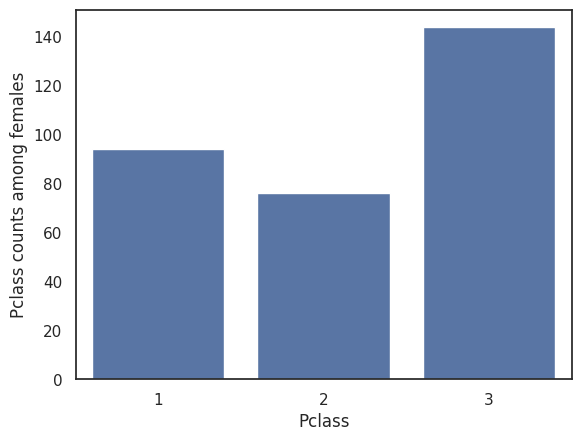

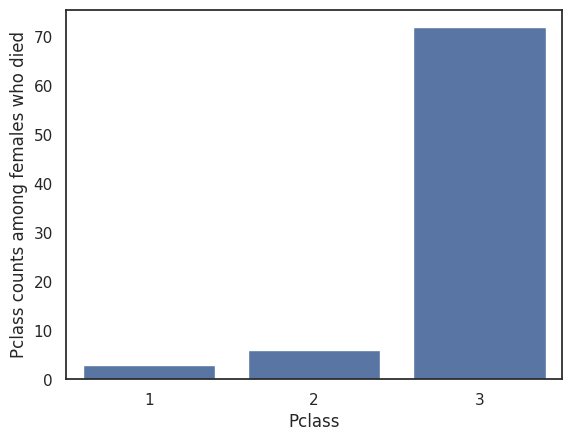

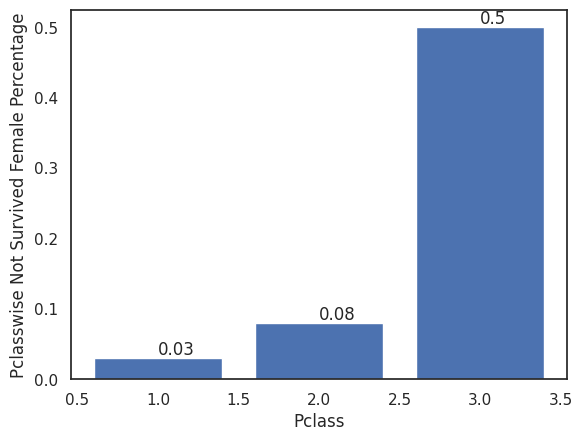

In [7]:
#Pclass might have played some role in not survival as priority among same gender type may be based on that
#So let us examine Pclass among the females who did not survive.

#First overall Pclass distribution among females
ax=sns.countplot(x="Pclass", data=trdf.loc[ (trdf.loc[:,"Sex"]=='female'), :])
ax.set_ylabel('Pclass counts among females')

#Now Pclass among females who died
plt.figure()

ax=sns.countplot(x="Pclass", data=trdf.loc[ (trdf.loc[:,"Sex"]=='female') & (trdf.loc[:,"Survived"]==0), :])
ax.set_ylabel('Pclass counts among females who died')

counts=trdf.loc[ trdf.loc[:,"Sex"]=='female' ,["Sex", "Pclass"]].groupby("Pclass").count()

#Following is the other way
counts=trdf.loc[ trdf.loc[:,"Sex"]=='female' ,["Sex", "Pclass"]].groupby("Pclass")["Sex"].count()
#other way ends

total_n_females_Pclasswise=counts.tolist()


not_survived_n_females_Pclasswise = trdf.loc[ (trdf.loc[:,"Sex"]=='female') & (trdf.loc[:, "Survived"]==0) ,["Sex", "Pclass"]].groupby("Pclass")["Sex"].count().tolist()

plt.figure()
height1=[round(i/j,2) for i, j in zip(not_survived_n_females_Pclasswise, total_n_females_Pclasswise)]

plt.bar(x=[1,2,3], height=height1)
plt.xlabel("Pclass")
plt.ylabel("Pclasswise Not Survived Female Percentage")

for i, h in zip([1,2,3],height1):
    plt.text(i,h+0.005,str(h))

#The output clearly shows that the Pclass did matter

<Axes: xlabel='Age', ylabel='Survived'>

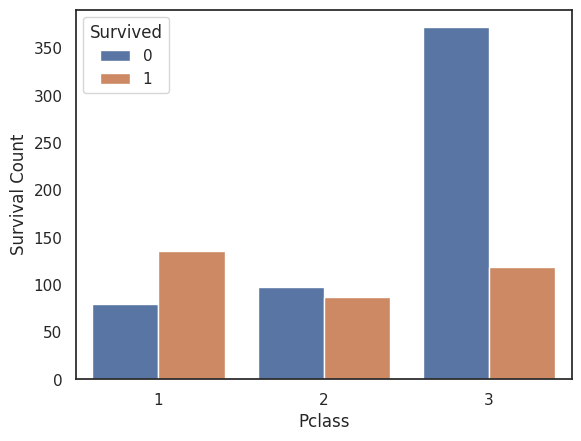

<Figure size 640x480 with 0 Axes>

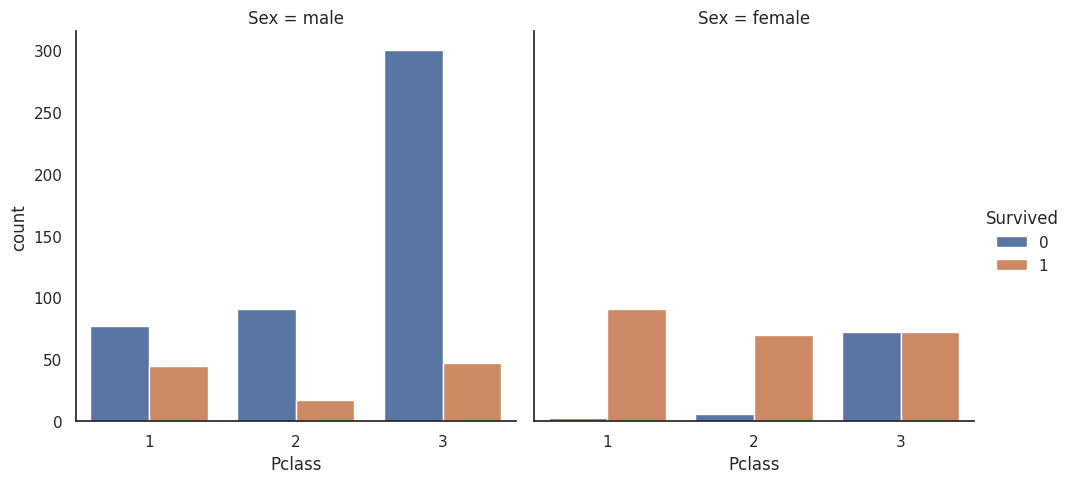

<Figure size 640x480 with 0 Axes>

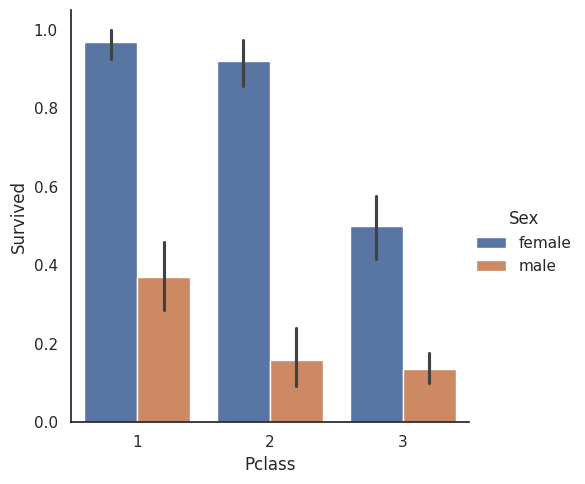

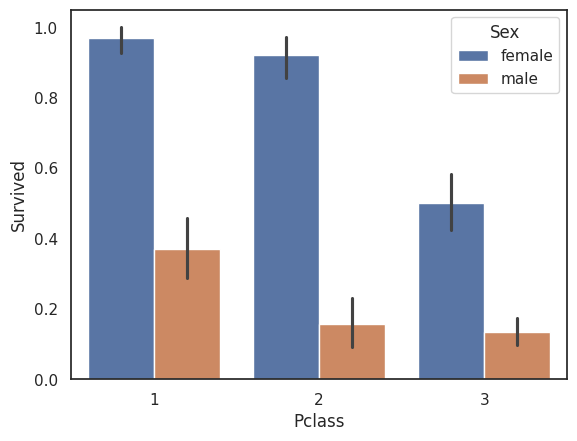

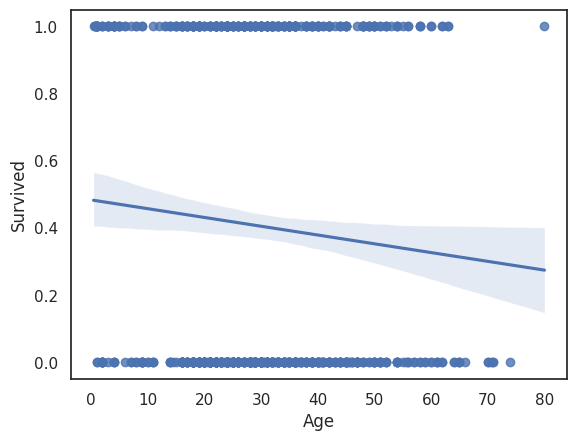

In [8]:
#Let us try some visualization

#count plot Pclasswise survival
ax=sns.countplot(x="Pclass", hue="Survived", data=trdf) #cannot take both x and y
ax.set_ylabel("Survival Count")

#count plots for Pclasswise and Genderwise Survival
plt.figure()
sns.catplot(x="Pclass", hue="Survived", col="Sex", data=trdf, kind="count")

#Let us see barplot of Pclasswise and Genderwise Survival
plt.figure()
sns.catplot(x="Pclass", y="Survived", hue="Sex", data=trdf, kind="bar")
#Another way for the same thing
plt.figure()
sns.barplot(x="Pclass", y="Survived", hue="Sex", data=trdf)

#Let us try to see relation between Survival and Age
plt.figure()
sns.regplot(x="Age", y="Survived", data=trdf)

In [9]:
#Impute missing age Salutationwise

#first let us create an attribute Salutation

#For training data
trdf["Salutation"]=trdf.loc[:, "Name"].str.extract(pat='([a-zA-Z]+)\.', expand=False)
print(trdf["Salutation"].unique())

#For testing data
tsdf["Salutation"]=tsdf.loc[:, "Name"].str.extract(pat='([a-zA-Z]+)\.', expand=False)

#Let us use below mapping to combine some of the common salutations
mapping={'Mlle': 'Miss', 'Major': 'Mr', 'Col': 'Mr', 'Sir': 'Mr', 'Don': 'Mr', 'Mme': 'Miss',
          'Jonkheer': 'Mr', 'Lady': 'Mrs', 'Capt': 'Mr', 'Countess': 'Mrs', 'Ms': 'Miss', 'Dona': 'Mrs'}

trdf.replace({"Salutation":mapping}, inplace=True)
tsdf.replace({"Salutation":mapping}, inplace=True)
print(trdf["Salutation"].unique())

#get the meadian age Salutationwise
temp=trdf.loc[:,["Age", "Salutation"]].groupby("Salutation")["Age"].median()

#do the imputation now
for i in range(len(temp.index)):
    trdf.loc[ trdf.loc[:,"Salutation"]==temp.index[i] , "Age"]=temp[i]
    tsdf.loc[ tsdf.loc[:,"Salutation"]==temp.index[i] , "Age"]=temp[i]

['Mr' 'Mrs' 'Miss' 'Master' 'Don' 'Rev' 'Dr' 'Mme' 'Ms' 'Major' 'Lady'
 'Sir' 'Mlle' 'Col' 'Capt' 'Countess' 'Jonkheer']
['Mr' 'Mrs' 'Miss' 'Master' 'Rev' 'Dr']


In [10]:
#Construct a new attribute let us name 'GenderPlus' with possible values female, boy and male
#We suspect that boys will have better chance of survival than adult males
trdf["GenderPlus"]=trdf["Sex"]
tsdf["GenderPlus"]=tsdf["Sex"]

trdf.loc[ trdf.loc[:,"Salutation"]=="Master", "GenderPlus"]="boy"
tsdf.loc[ tsdf.loc[:,"Salutation"]=="Master", "GenderPlus"]="boy"

In [11]:
#Visualize survuval percentage of boys vs adult males
n_males_survived=trdf.loc[ (trdf.loc[:,"GenderPlus"]=='male') & (trdf.loc[:,"Survived"]==1) ,"GenderPlus"].count()
n_males=trdf.loc[ trdf.loc[:,"GenderPlus"]=='male' ,"GenderPlus"].count()
surv_perc_of_males= round(n_males_survived/n_males,2)
print(surv_perc_of_males)

n_boys_survived=trdf.loc[ (trdf.loc[:,"GenderPlus"]=='boy') & (trdf.loc[:,"Survived"]==1) ,"GenderPlus"].count()
n_boys=trdf.loc[ trdf.loc[:,"GenderPlus"]=='boy' ,"GenderPlus"].count()
surv_perc_of_boys= round(n_boys_survived/n_boys,2)
print(surv_perc_of_boys)

#From output it is clear that boys have better chance of being survived than adult males and therefore GenderPlus can be useful

0.16
0.57


In [12]:
#Construct Family Size, we may use it.
trdf["Family_Size"]=trdf["SibSp"]+trdf["Parch"]+1
tsdf["Family_Size"]=tsdf["SibSp"]+tsdf["Parch"]+1

In [13]:
#Construct FamilySurvivalRate
#The hypothesis is that if somebody from a family of a passenger under focus is survived then the chances of that passenger
#survived is also more

#First combine train and test
data=pd.concat([trdf,tsdf], axis=0, ignore_index=True)

#Add surname as it can help identify family

data["Surname"]=data.loc[:,"Name"].str.split(pat=",").str[0]
#print(type(data.loc[:,"Name"].str.split(pat=",")))
#print(data.loc[:,"Name"].str.split(pat=",").str[0])

#Add Family_Survival_Rate

data["FamilySurvivalRate"]=0.5

for grpid, grpdf in data.groupby("Surname"):
    if len(grpdf) > 1:
        for ind, row in grpdf.iterrows():
            smax=grpdf.drop(ind).loc[:, "Survived"].max()
            smin=grpdf.drop(ind).loc[:, "Survived"].min()
            pid=row["PassengerId"]

            if smax == 1:
                data.loc[ data.loc[:,"PassengerId"]==pid, "FamilySurvivalRate"]=1
            elif smin==0:
                data.loc[ data.loc[:,"PassengerId"]==pid, "FamilySurvivalRate"]=0

#Same ticket is also an indication of the same family
for grpid1, grpdf1 in data.groupby("Ticket"):
    if len(grpdf1) > 1:
        for ind, row in grpdf1.iterrows():
            smax=grpdf1.drop(ind).loc[:, "Survived"].max()
            smin=grpdf1.drop(ind).loc[:, "Survived"].min()
            pid=row["PassengerId"]

            if smax == 1:
                data.loc[ data.loc[:,"PassengerId"]==pid, "FamilySurvivalRate"]=1
            elif smin==0:
                data.loc[ data.loc[:,"PassengerId"]==pid, "FamilySurvivalRate"]=0

#drop Salutation and Surname as they are no longer required
#data.drop(columns=["Salutation", "Surname"], inplace=True)

#split back to trdf and tsdf

trdf=data.loc[0:890,:].copy()
tsdf=data.loc[891:,:].copy()

#label encoding of GenderPlus and Sex
lec=LabelEncoder()
lec.fit(trdf.loc[:,"GenderPlus"])
trdf.loc[:,"GenderPlus"]=lec.transform(trdf.loc[:,"GenderPlus"])
tsdf.loc[:,"GenderPlus"]=lec.transform(tsdf.loc[:,"GenderPlus"])

lec=LabelEncoder()
lec.fit(trdf.loc[:,"Sex"])
trdf.loc[:,"Sex"]=lec.transform(trdf.loc[:,"Sex"])
tsdf.loc[:,"Sex"]=lec.transform(tsdf.loc[:,"Sex"])

In [14]:
#There is missing value in Fare in test data. Let us impute it first.
tsdf["Fare"].fillna(trdf["Fare"].mean(), inplace=True)

#Create Fare_Code column but before that create Fare_Bins
trdf["Fare_Bins"], bins=pd.qcut(trdf["Fare"], q=5, retbins=True)

lec=LabelEncoder()
lec.fit(trdf["Fare_Bins"])
trdf["Fare_Code"]=lec.transform(trdf["Fare_Bins"])

tsdf["Fare_Bins"]=pd.cut(tsdf["Fare"], bins=bins, include_lowest=True)

tsdf["Fare_Code"]=lec.transform(tsdf["Fare_Bins"])


In [15]:
x = trdf.loc[:, ["GenderPlus", "Pclass", "FamilySurvivalRate", "Family_Size", "Sex"]].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   GenderPlus          891 non-null    object 
 1   Pclass              891 non-null    int64  
 2   FamilySurvivalRate  891 non-null    float64
 3   Family_Size         891 non-null    int64  
 4   Sex                 891 non-null    object 
dtypes: float64(1), int64(2), object(2)
memory usage: 34.9+ KB


In [16]:
from sklearn.ensemble import IsolationForest


In [17]:
# ========================
# 1. Imports
# ========================
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import IsolationForest

# ========================
# 2. Feature selection
# ========================
X = trdf.loc[:, [
    "GenderPlus",
    "Pclass",
    "FamilySurvivalRate",
    "Family_Size",
    "Sex"
]]

# ========================
# 3. Column split
# ========================
categorical_cols = ["Sex"]
numeric_cols = [
    "GenderPlus",
    "Pclass",
    "FamilySurvivalRate",
    "Family_Size"
]

# ========================
# 4. Preprocessor (THIS WAS MISSING)
# ========================
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_cols),
        ("num", StandardScaler(), numeric_cols),
    ]
)

# ========================
# 5. Isolation Forest pipeline
# ========================
pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", IsolationForest(
        n_estimators=200,
        contamination=0.05,
        random_state=42
    ))
])

# ========================
# 6. Fit
# ========================
pipeline.fit(X)

# ========================
# 7. Anomaly score + flag
# ========================
X_processed = pipeline.named_steps["preprocess"].transform(X)

anomaly_score = pipeline.named_steps["model"].decision_function(X_processed)
anomaly_flag = (pipeline.named_steps["model"].predict(X_processed) == -1).astype(int)

# ========================
# 8. Attach results
# ========================
iso_df = trdf.copy()
iso_df["Anomaly_Score"] = anomaly_score
iso_df["Anomaly"] = anomaly_flag

iso_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   PassengerId         891 non-null    int64   
 1   Survived            891 non-null    float64 
 2   Pclass              891 non-null    int64   
 3   Name                891 non-null    object  
 4   Sex                 891 non-null    object  
 5   Age                 891 non-null    float64 
 6   SibSp               891 non-null    int64   
 7   Parch               891 non-null    int64   
 8   Ticket              891 non-null    object  
 9   Fare                891 non-null    float64 
 10  Cabin               204 non-null    object  
 11  Embarked            889 non-null    object  
 12  Salutation          891 non-null    object  
 13  GenderPlus          891 non-null    object  
 14  Family_Size         891 non-null    int64   
 15  Surname             891 non-null    obje

In [18]:
# ========================
# Define anomaly index
# ========================
anomaly_index = iso_df.loc[iso_df["Anomaly"] == 1].index.tolist()

# ========================
# Training data
# ========================
X_train = trdf.loc[:, [
    "GenderPlus",
    "Pclass",
    "FamilySurvivalRate",
    "Family_Size",
    "Sex"
]]
y_train = trdf.loc[:, "Survived"]

# Remove anomalies
X_train = X_train.drop(anomaly_index)
y_train = y_train.drop(anomaly_index)

# Test data
X_test = tsdf.loc[:, [
    "GenderPlus",
    "Pclass",
    "FamilySurvivalRate",
    "Family_Size",
    "Sex"
]]


In [19]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


In [20]:
categorical_cols = ["Sex", "GenderPlus"]
numeric_cols = ["Pclass", "FamilySurvivalRate", "Family_Size"]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_cols),
        ("num", StandardScaler(), numeric_cols),
    ]
)


In [21]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV


In [22]:
pipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", XGBClassifier(
        eval_metric="logloss",
        use_label_encoder=False,
        random_state=42
    ))
])


In [23]:
param_grid = {
    "model__max_depth": [3, 4],
    "model__n_estimators": [50, 100],
    "model__learning_rate": [0.05, 0.1]
}

clf_gs = GridSearchCV(
    pipe,
    param_grid,
    cv=5,
    verbose=2,
    n_jobs=1
)

clf_gs.fit(X_train, y_train)

print("Best params:", clf_gs.best_params_)


Fitting 5 folds for each of 8 candidates, totalling 40 fits
[CV] END model__learning_rate=0.05, model__max_depth=3, model__n_estimators=50; total time=   0.1s
[CV] END model__learning_rate=0.05, model__max_depth=3, model__n_estimators=50; total time=   0.0s
[CV] END model__learning_rate=0.05, model__max_depth=3, model__n_estimators=50; total time=   0.0s
[CV] END model__learning_rate=0.05, model__max_depth=3, model__n_estimators=50; total time=   0.0s
[CV] END model__learning_rate=0.05, model__max_depth=3, model__n_estimators=50; total time=   0.0s
[CV] END model__learning_rate=0.05, model__max_depth=3, model__n_estimators=100; total time=   0.0s
[CV] END model__learning_rate=0.05, model__max_depth=3, model__n_estimators=100; total time=   0.0s
[CV] END model__learning_rate=0.05, model__max_depth=3, model__n_estimators=100; total time=   0.0s
[CV] END model__learning_rate=0.05, model__max_depth=3, model__n_estimators=100; total time=   0.0s
[CV] END model__learning_rate=0.05, model__ma

# Implementing XGBoost, Random Forest, Gradient Boosting classifier, LOgistic Regression , and then comparing all 4 of them. 

In [24]:
from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)


In [25]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier


In [26]:
models = {
    "XGBoost": XGBClassifier(
        max_depth=clf_gs.best_params_["model__max_depth"],
        n_estimators=clf_gs.best_params_["model__n_estimators"],
        learning_rate=clf_gs.best_params_["model__learning_rate"],
        eval_metric="logloss",
        random_state=42
    ),

    "RandomForest": RandomForestClassifier(
        n_estimators=200,
        max_depth=6,
        random_state=42
    ),

    "GradientBoosting": GradientBoostingClassifier(
        n_estimators=150,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),

    "LogisticRegression": LogisticRegression(
        max_iter=1000,
        random_state=42
    )
}


In [27]:
from sklearn.metrics import classification_report
import pandas as pd

results = {}

for name, model in models.items():
    pipe = Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", model)
    ])

    pipe.fit(X_tr, y_tr)
    y_pred = pipe.predict(X_val)

    print(f"\n{'='*60}")
    print(f"Classification Report: {name}")
    print(f"{'='*60}")
    print(classification_report(y_val, y_pred))

    report = classification_report(y_val, y_pred, output_dict=True)
    results[name] = {
        "Accuracy": report["accuracy"],
        "Precision": report["weighted avg"]["precision"],
        "Recall": report["weighted avg"]["recall"],
        "F1-score": report["weighted avg"]["f1-score"]
    }



Classification Report: XGBoost
              precision    recall  f1-score   support

         0.0       0.85      0.94      0.89       107
         1.0       0.88      0.71      0.79        63

    accuracy                           0.86       170
   macro avg       0.87      0.83      0.84       170
weighted avg       0.86      0.86      0.86       170


Classification Report: RandomForest
              precision    recall  f1-score   support

         0.0       0.85      0.94      0.89       107
         1.0       0.88      0.71      0.79        63

    accuracy                           0.86       170
   macro avg       0.87      0.83      0.84       170
weighted avg       0.86      0.86      0.86       170


Classification Report: GradientBoosting
              precision    recall  f1-score   support

         0.0       0.84      0.94      0.89       107
         1.0       0.88      0.70      0.78        63

    accuracy                           0.85       170
   macro avg      

In [28]:
results_df = pd.DataFrame(results).T
print(results_df)


                    Accuracy  Precision    Recall  F1-score
XGBoost             0.858824   0.861196  0.858824  0.855141
RandomForest        0.858824   0.861196  0.858824  0.855141
GradientBoosting    0.852941   0.855873  0.852941  0.848693
LogisticRegression  0.841176   0.841640  0.841176  0.837463


<Figure size 4500x1200 with 0 Axes>

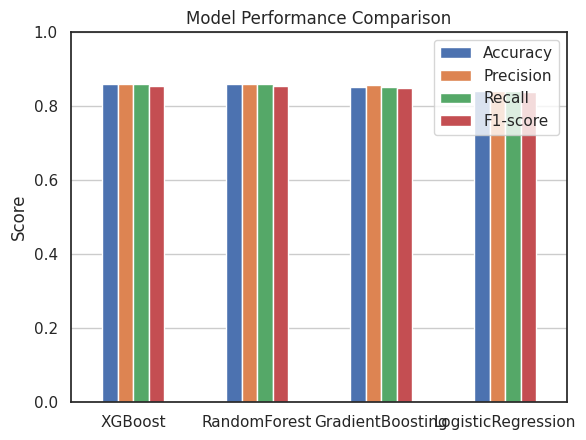

In [29]:
plt.figure(figsize=(45,12))
results_df.plot(kind="bar")
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0,1)
plt.grid(axis="y")
plt.xticks(rotation=0)
plt.show()


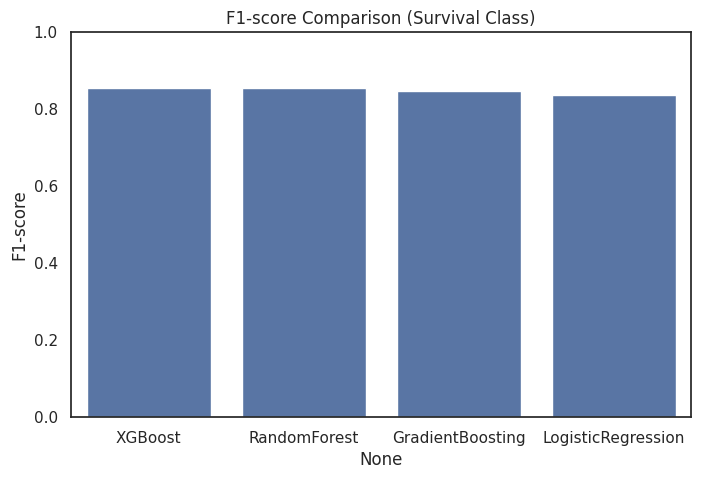

In [30]:
plt.figure(figsize=(8,5))
sns.barplot(x=results_df.index, y=results_df["F1-score"])
plt.title("F1-score Comparison (Survival Class)")
plt.ylabel("F1-score")
plt.ylim(0,1)
plt.show()


Key observation:
All models perform well (>84% accuracy), indicating that feature engineering (GenderPlus, FamilySurvivalRate, FamilySize) plays a dominant role.

1.  Overall Observations

XGBoost and Random Forest show identical and best performance across all metrics.

Gradient Boosting performs slightly lower but remains competitive.

Logistic Regression, being a linear model, performs the weakest among the four, though still reasonably well.





2. Metric-wise Interpretation

Accuracy

XGBoost & Random Forest achieve the highest accuracy (~85.9%).

Logistic Regression has the lowest accuracy (~84.1%).


Precision

XGBoost and Random Forest have the highest precision, meaning fewer false positives.

Logistic Regression shows slightly lower precision.


Recall

All models perform well for class 0, but class 1 recall is lower, indicating difficulty in detecting the minority class.

Tree-based models handle this imbalance better than Logistic Regression.


F1-score

F1-score confirms the same ranking:

XGBoost ≈ Random Forest > Gradient Boosting > Logistic Regression


| Model               | Accuracy | Precision | Recall | F1-score |
|---------------------|----------|-----------|--------|----------|
| XGBoost             | 0.8588   | 0.8612    | 0.8588 | 0.8551   |
| Random Forest       | 0.8588   | 0.8612    | 0.8588 | 0.8551   |
| Gradient Boosting   | 0.8529   | 0.8559    | 0.8529 | 0.8487   |
| Logistic Regression | 0.8412   | 0.8416    | 0.8412 | 0.8375   |
